In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Load dataset
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


# Clean numeric fields
def extract_number(x):
    if pd.isna(x): return None
    x = str(x).replace(',', '')
    m = re.search(r'(\d+(\.\d+)?)', x)
    return float(m.group(1)) if m else None

data['RAM_GB'] = data['RAM'].apply(extract_number)
data['Battery_mAh'] = data['Battery Capacity'].apply(extract_number)
data['Screen_in'] = data['Screen Size'].apply(extract_number)
data['Weight_g'] = data['Mobile Weight'].apply(extract_number)

# Clean price
def clean_price(x):
    if pd.isna(x): return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data['Launched Price (India)'] = data['Launched Price (India)'].apply(clean_price)
data.rename(columns={'Launched Price (India)': 'Price_INR'}, inplace=True)

# Calculate correlations
corrs = data[['RAM_GB','Battery_mAh','Screen_in','Weight_g','Price_INR']].corr()

# Make output folder
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)


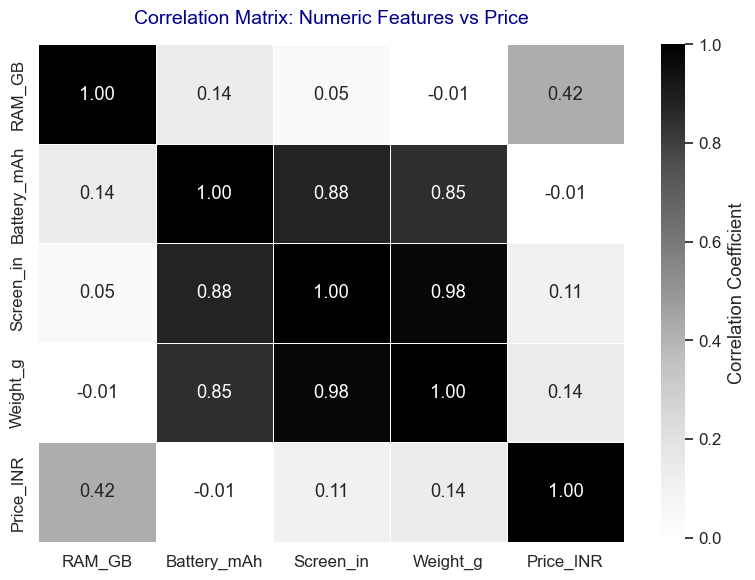

In [7]:
plt.figure(figsize=(8,6))

sns.set(style="whitegrid", font_scale=1.1)

# Use a visually strong diverging colormap
sns.heatmap(
    corrs,
    annot=True,
    fmt=".2f",
    cmap='Greys',    # red-yellow-blue reversed for strong contrast
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Matrix: Numeric Features vs Price', fontsize=14, color='darkblue', pad=15)
plt.tight_layout()
plt.savefig(out_dir / "correlation_matrix.png", dpi=300)
plt.show()


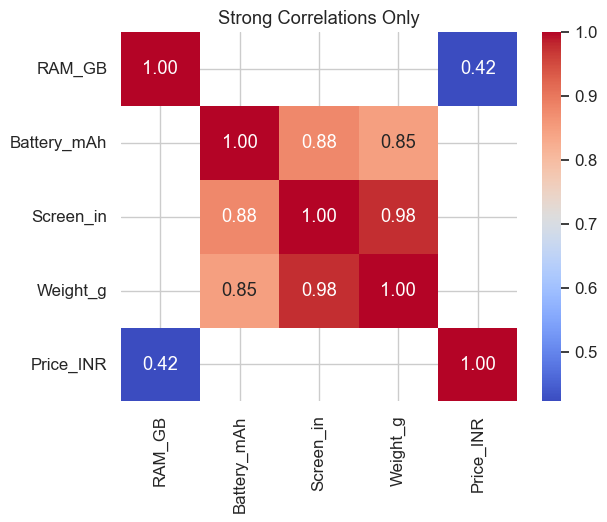

In [9]:
strong_corrs = corrs[(corrs >= 0.3) | (corrs <= -0.3)]
sns.heatmap(strong_corrs, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Strong Correlations Only")
plt.show()
